# RNA 3D Folding Model - Technical Validation (Tier 1)

This notebook implements Tier 1 validation for the RNA 3D folding model. The focus is on fast verification of model functionality and basic technical performance.

**Characteristics:**
- Quick to run (<5 minutes)
- Uses small subset of data (3-5 sequences)
- Focuses on shape checks, gradient flow, and basic metrics

In [1]:
import os
import sys
import time
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# Robust path handling functions
def find_project_root():
    """Find the project root directory using multiple strategies."""
    # Strategy 1: Look up from current directory
    current_dir = os.path.abspath(os.getcwd())
    
    # Strategy 2: Use a marker file/directory to identify the project root
    markers = ["src", "data", "environment.yml", "README.md"]
    
    # First, try to find markers from the current directory
    test_dir = current_dir
    max_levels = 3  # Don't go up too many levels
    
    for _ in range(max_levels):
        marker_count = sum(1 for marker in markers if os.path.exists(os.path.join(test_dir, marker)))
        if marker_count >= 2:  # At least 2 markers found
            return test_dir
        parent_dir = os.path.dirname(test_dir)
        if parent_dir == test_dir:  # Reached root directory
            break
        test_dir = parent_dir
    
    # If we couldn't find the project root, fall back to parent.parent
    fallback_root = os.path.abspath(os.path.join(current_dir, "..", ".."))
    print(f"Warning: Could not definitively locate project root. Using fallback: {fallback_root}")
    return fallback_root

# Find project root and convert to absolute path
project_root = find_project_root()
print(f"Project root identified as: {project_root}")
sys.path.insert(0, project_root)

# Import project modules
from src.models.rna_folding_model import RNAFoldingModel
from src.data_loading import RNADataset
from src.utils.structure_metrics import compute_rmsd, compute_tm_score, compute_per_residue_rmsd

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Project root identified as: /home/smcgee/MLprojects/RNA 2025/Pipeline-v1-March27on/RNA-2025-Pipeline-v0.2.0-BetaBend
Using device: cuda


## 1. Configuration

Define validation parameters and model configuration.

In [2]:
# Validation configuration
CONFIG = {
    # Data configuration
    "data_dir": os.path.join(project_root, "data", "processed"),
    "subset_size": 5,  # Number of sequences to use for validation
    
    # Model configuration
    "model_config": {
        "d_model": 256,
        "d_feedforward": 1024,
        "num_layers": 4,
        "num_heads": 8,
        "dropout": 0.1,
        "ipa_dropout": 0.1,
        "use_checkpointing": False
    },
    
    # Paths
    "results_dir": os.path.join(project_root, "validation", "tier1_technical", "results"),
    "checkpoint_path": None,  # Path to model checkpoint (if available)
    
    # Runtime options
    "random_seed": 42,
    "batch_size": 2,
    "num_workers": 2
}

# Create results directory if it doesn't exist
os.makedirs(CONFIG["results_dir"], exist_ok=True)

# Enhanced path verification helper function
def verify_data_paths(data_dir):
    """Verify that all necessary data directories exist and provide robust fallbacks."""
    print(f"Verifying data paths from base directory: {data_dir}")
    
    # Check if the data directory exists
    if not os.path.exists(data_dir):
        print(f"WARNING: Data directory does not exist: {data_dir}")
        # Try to find the data directory using alternative methods
        alternatives = [
            os.path.join(project_root, "data", "processed"),
            os.path.join(project_root, "data"),
            os.path.join(os.path.dirname(project_root), "data", "processed"),
            os.path.join(os.path.dirname(project_root), "data"),
        ]
        
        for alt_dir in alternatives:
            if os.path.exists(alt_dir):
                print(f"Found alternative data directory: {alt_dir}")
                data_dir = alt_dir
                CONFIG["data_dir"] = data_dir  # Update the configuration
                break
        else:
            print("ERROR: Could not find a valid data directory")
    
    # Define the feature subdirectories to check
    feature_dirs = {
        "dihedral_features": os.path.join(data_dir, "dihedral_features"),
        "thermo_features": os.path.join(data_dir, "thermo_features"),
        "mi_features": os.path.join(data_dir, "mi_features")
    }
    
    all_exist = True
    found_dirs = {}
    
    # Check each feature directory
    for feature_type, dir_path in feature_dirs.items():
        if os.path.exists(dir_path):
            # Count files to verify content
            files = [f for f in os.listdir(dir_path) if f.endswith('.npz')]
            print(f"Found {len(files)} files in {dir_path}")
            found_dirs[feature_type] = dir_path
        else:
            print(f"WARNING: Feature directory not found: {dir_path}")
            all_exist = False
            
            # Try alternative locations for feature directories
            for subdir in ["", "processed", "features"]:
                alt_path = os.path.join(data_dir, subdir, feature_type)
                if os.path.exists(alt_path):
                    files = [f for f in os.listdir(alt_path) if f.endswith('.npz')]
                    print(f"Found alternative directory with {len(files)} files: {alt_path}")
                    found_dirs[feature_type] = alt_path
                    break
    
    # Print summary
    print("\nPath verification summary:")
    for feature_type, path in found_dirs.items():
        print(f"  {feature_type}: {path}")
        
    for feature_type in feature_dirs:
        if feature_type not in found_dirs:
            print(f"  {feature_type}: NOT FOUND")
    
    return found_dirs if found_dirs else None

# Verify data paths and get the valid feature directories
feature_dirs = verify_data_paths(CONFIG["data_dir"])

# Update config with the verified feature directories if found
if feature_dirs:
    CONFIG["feature_dirs"] = feature_dirs
else:
    print("ERROR: No valid feature directories found. Validation will likely fail.")

Verifying data paths from base directory: /home/smcgee/MLprojects/RNA 2025/Pipeline-v1-March27on/RNA-2025-Pipeline-v0.2.0-BetaBend/data/processed
Found 855 files in /home/smcgee/MLprojects/RNA 2025/Pipeline-v1-March27on/RNA-2025-Pipeline-v0.2.0-BetaBend/data/processed/dihedral_features
Found 856 files in /home/smcgee/MLprojects/RNA 2025/Pipeline-v1-March27on/RNA-2025-Pipeline-v0.2.0-BetaBend/data/processed/thermo_features
Found 856 files in /home/smcgee/MLprojects/RNA 2025/Pipeline-v1-March27on/RNA-2025-Pipeline-v0.2.0-BetaBend/data/processed/mi_features

Path verification summary:
  dihedral_features: /home/smcgee/MLprojects/RNA 2025/Pipeline-v1-March27on/RNA-2025-Pipeline-v0.2.0-BetaBend/data/processed/dihedral_features
  thermo_features: /home/smcgee/MLprojects/RNA 2025/Pipeline-v1-March27on/RNA-2025-Pipeline-v0.2.0-BetaBend/data/processed/thermo_features
  mi_features: /home/smcgee/MLprojects/RNA 2025/Pipeline-v1-March27on/RNA-2025-Pipeline-v0.2.0-BetaBend/data/processed/mi_feature

In [3]:
# Add the validation directory to path to import the CSV data loader
import sys
validation_dir = os.path.join(project_root, "validation")
if validation_dir not in sys.path:
    sys.path.insert(0, validation_dir)

# Import the CSV data loader
from csv_data_loader import CSVDataLoader

print("Loading data directly from CSV files instead of processed NPZ features...")
csv_loader = CSVDataLoader(data_dir=os.path.join(project_root, "data"), split="validation")

# Create dataset
torch_dataset = csv_loader.create_torch_dataset(
    subset_size=CONFIG["subset_size"],
    seed=CONFIG["random_seed"]
)

# Create validation dataloader
validation_loader = torch.utils.data.DataLoader(
    torch_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    collate_fn=torch_dataset.collate_fn
)

print(f"Created validation dataloader with {len(torch_dataset)} samples")

Loading data directly from CSV files instead of processed NPZ features...
Loaded 12 sequences for validation split
First few IDs: R1107, R1108, R1116, R1117v2, R1126
Created validation dataloader with 5 samples


## 3. Initialize Model

Create model instance and load checkpoint if available.

In [4]:
def initialize_model(config, checkpoint_path=None):
    """Initialize model and load checkpoint if available."""
    # Print full model config for debugging
    print("Model configuration:")
    for key, value in config["model_config"].items():
        print(f"  {key}: {value}")
    
    # Initialize the model with all required parameters
    model = RNAFoldingModel(
        d_model=config["model_config"]["d_model"],
        d_feedforward=config["model_config"]["d_feedforward"],
        num_blocks=config["model_config"]["num_layers"],
        num_attention_heads=config["model_config"]["num_heads"],
        dropout=config["model_config"]["dropout"],
        ipa_dropout=config["model_config"]["ipa_dropout"],
        use_checkpointing=config["model_config"]["use_checkpointing"]
    )
    
    if checkpoint_path and os.path.exists(checkpoint_path):
        print(f"Loading checkpoint from {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        print("Initializing model with random weights")
    
    model = model.to(device)
    return model

# Initialize model
model = initialize_model(CONFIG, CONFIG["checkpoint_path"])

Model configuration:
  d_model: 256
  d_feedforward: 1024
  num_layers: 4
  num_heads: 8
  dropout: 0.1
  ipa_dropout: 0.1
  use_checkpointing: False
Initializing model with random weights


## 4. Model Shape Check

Verify input and output tensor shapes with a sample batch.

In [5]:
def check_model_shapes(model, dataloader):
    """Check model input and output shapes with a sample batch."""
    batch = next(iter(dataloader))
    
    # Move batch to device
    for key in batch:
        if isinstance(batch[key], torch.Tensor):
            batch[key] = batch[key].to(device)
    
    # Set model to eval mode
    model.eval()
    
    # Forward pass
    with torch.no_grad():
        outputs = model(batch)
    
    # Print input shapes
    print("\nInput shapes:")
    for key, value in batch.items():
        if isinstance(value, torch.Tensor):
            print(f"  {key}: {value.shape}")
    
    # Print output shapes
    print("\nOutput shapes:")
    for key, value in outputs.items():
        if isinstance(value, torch.Tensor):
            print(f"  {key}: {value.shape}")
            
    # Return batch and outputs for further analysis
    return batch, outputs

batch, outputs = check_model_shapes(model, validation_loader)

INFO: Creating adjusted projection layer with in_features=73
INFO: pairing_probs shape: torch.Size([2, 135, 135])
INFO: coupling_matrix shape: torch.Size([2, 135, 135])
INFO: rel_pos_batch shape: torch.Size([2, 135, 135, 32])
INFO: pair_features_list[0] shape: torch.Size([2, 135, 135, 1])
INFO: pair_features_list[1] shape: torch.Size([2, 135, 135, 1])
INFO: pair_features_list[2] shape: torch.Size([2, 135, 135, 32])



Input shapes:
  lengths: torch.Size([2])
  sequence_int: torch.Size([2, 135])
  mask: torch.Size([2, 135])
  atom_mask: torch.Size([2, 135])
  angle_mask: torch.Size([2, 135])
  atom_positions: torch.Size([2, 135, 3])
  dihedral_features: torch.Size([2, 135, 39])
  dihedral_angles: torch.Size([2, 135, 4])
  pairing_probs: torch.Size([2, 135, 135])
  positional_entropy: torch.Size([2, 135])
  accessibility: torch.Size([2, 135])
  coupling_matrix: torch.Size([2, 135, 135])

Output shapes:
  pred_coords: torch.Size([2, 135, 3])
  pred_confidence: torch.Size([2, 135])
  pred_angles: torch.Size([2, 135, 4])


## 5. Gradient Flow Check

Verify gradient flow through the model.

In [6]:
def check_gradient_flow(model, batch):
    """Verify gradient flow through the model."""
    # Set model to train mode
    model.train()
    
    # Clear gradients
    model.zero_grad()
    
    # Forward pass
    outputs = model(batch)
    
    # Map model output keys to the expected keys for the loss functions
    # The model might return keys like 'pred_coords' but loss functions expect 'final_atom_positions'
    if "pred_coords" in outputs and "final_atom_positions" not in outputs:
        outputs["final_atom_positions"] = outputs["pred_coords"]
    
    if "pred_angles" in outputs and "predicted_angles" not in outputs:
        outputs["predicted_angles"] = outputs["pred_angles"]
        
    if "pred_confidence" in outputs and "predicted_confidence" not in outputs:
        outputs["predicted_confidence"] = outputs["pred_confidence"]
    
    # Compute loss
    from src.losses import compute_stable_fape_loss, compute_angle_loss
    
    # FAPE loss
    fape_loss = compute_stable_fape_loss(
        pred_coords=outputs.get("final_atom_positions", outputs.get("pred_coords")),
        true_coords=batch["atom_positions"],
        mask=batch["atom_mask"],
        clamp_value=10.0
    )
    
    # Angle loss (if angles are predicted)
    angle_loss = 0.0
    if "predicted_angles" in outputs or "pred_angles" in outputs:
        angle_key = "predicted_angles" if "predicted_angles" in outputs else "pred_angles"
        angle_loss = compute_angle_loss(
            pred_angles=outputs[angle_key],
            true_angles=batch["dihedral_angles"],
            mask=batch["angle_mask"],
            loss_type="mse"
        )
    
    # Total loss
    total_loss = fape_loss + 0.5 * angle_loss
    print(f"\nLoss values:")
    print(f"  FAPE loss: {fape_loss.item():.4f}")
    print(f"  Angle loss: {angle_loss if isinstance(angle_loss, float) else angle_loss.item():.4f}")
    print(f"  Total loss: {total_loss.item():.4f}")
    
    # Backward pass
    total_loss.backward()
    
    # Check gradients
    print("\nGradient flow check:")
    
    # Parameters that should always have gradients
    critical_params = [
        "transformer_blocks",
        "ipa_module"
    ]
    
    # Parameters that may not have gradients
    allowed_no_grad_params = [
        "embedding_module.relative_pos_encoding.embeddings.weight",
        "embedding_module.sequence_embedding.embedding.weight"
    ]
    
    # Track parameters with/without gradients
    parameters_with_gradient = []
    parameters_without_gradient = []
    
    for name, param in model.named_parameters():
        if param.grad is None:
            if name in allowed_no_grad_params:
                # This parameter is allowed to have no gradient
                continue
            parameters_without_gradient.append(name)
        else:
            # Check if gradient is non-zero
            if param.grad.abs().sum().item() > 0:
                parameters_with_gradient.append(name)
            else:
                parameters_without_gradient.append(name)
    
    # Check critical parameters
    critical_missing_grad = []
    for critical in critical_params:
        if not any(critical in param for param in parameters_with_gradient):
            critical_missing_grad.append(critical)
    
    # Print results
    print(f"  Parameters with gradients: {len(parameters_with_gradient)}")
    print(f"  Parameters without gradients: {len(parameters_without_gradient)}")
    
    if critical_missing_grad:
        print(f"  WARNING: Critical components missing gradients: {critical_missing_grad}")
        # Show the parameters without gradients for debugging
        print("  Parameters without gradients:")
        for name in parameters_without_gradient:
            print(f"    {name}")
    else:
        print("  All critical components have gradients. ✓")
    
    # Return gradient status
    gradient_status = {
        "parameters_with_gradient": parameters_with_gradient,
        "parameters_without_gradient": parameters_without_gradient,
        "critical_missing_grad": critical_missing_grad,
        "loss": {
            "fape": fape_loss.item(),
            "angle": angle_loss if isinstance(angle_loss, float) else angle_loss.item(),
            "total": total_loss.item()
        }
    }
    
    return gradient_status

# Check gradient flow
gradient_status = check_gradient_flow(model, batch)

INFO: pairing_probs shape: torch.Size([2, 135, 135])
INFO: coupling_matrix shape: torch.Size([2, 135, 135])
INFO: rel_pos_batch shape: torch.Size([2, 135, 135, 32])
INFO: pair_features_list[0] shape: torch.Size([2, 135, 135, 1])
INFO: pair_features_list[1] shape: torch.Size([2, 135, 135, 1])
INFO: pair_features_list[2] shape: torch.Size([2, 135, 135, 32])



Loss values:
  FAPE loss: 9.9316
  Angle loss: 0.0386
  Total loss: 9.9509

Gradient flow check:
  Parameters with gradients: 59
  Parameters without gradients: 32
  All critical components have gradients. ✓


## 6. Structure Metrics Evaluation

Evaluate model predictions with structure metrics (RMSD, TM-score, per-residue RMSD).

In [7]:
def evaluate_structure_metrics(model, dataloader):
    """Evaluate model predictions with structure metrics."""
    model.eval()
    
    results = {
        "rmsd": [],
        "tm_score": [],
        "per_residue_rmsd": [],
        "ids": [],
        "sequence_lengths": []
    }
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            # Move batch to device
            for key in batch:
                if isinstance(batch[key], torch.Tensor):
                    batch[key] = batch[key].to(device)
            
            # Forward pass
            outputs = model(batch)
            
            # Get predictions and true coordinates - handle different key names
            pred_coords = None
            if "final_atom_positions" in outputs:
                pred_coords = outputs["final_atom_positions"]
            elif "pred_coords" in outputs:
                pred_coords = outputs["pred_coords"]
            else:
                print("Warning: No coordinate predictions found in model outputs")
                continue
                
            true_coords = batch["atom_positions"]
            atom_mask = batch["atom_mask"]
            
            # Calculate RMSD
            rmsd = compute_rmsd(pred_coords, true_coords, atom_mask)
            
            # Calculate TM-score
            tm_score = compute_tm_score(pred_coords, true_coords, atom_mask)
            
            # Calculate per-residue RMSD
            per_res_rmsd = compute_per_residue_rmsd(pred_coords, true_coords, atom_mask)
            
            # Handle both 0-dim tensor (scalar) and batch tensor cases
            batch_size = len(batch["ids"])
            
            # Store results - handle different tensor shapes
            for i in range(batch_size):
                results["ids"].append(batch["ids"][i])
                
                # Handle RMSD - could be scalar or batch
                if rmsd.dim() == 0:  # Scalar tensor
                    results["rmsd"].append(rmsd.item() if not torch.isnan(rmsd).item() else float('nan'))
                else:  # Batch tensor
                    results["rmsd"].append(rmsd[i].item() if not torch.isnan(rmsd[i]).item() else float('nan'))
                
                # Handle TM-score - could be scalar or batch
                if tm_score.dim() == 0:  # Scalar tensor
                    results["tm_score"].append(tm_score.item() if not torch.isnan(tm_score).item() else float('nan'))
                else:  # Batch tensor
                    results["tm_score"].append(tm_score[i].item() if not torch.isnan(tm_score[i]).item() else float('nan'))
                
                # Handle per-residue RMSD - could be scalar or batch
                if per_res_rmsd.dim() == 1:  # Single sequence
                    results["per_residue_rmsd"].append(per_res_rmsd.detach().cpu().numpy())
                else:  # Batch of sequences
                    results["per_residue_rmsd"].append(per_res_rmsd[i].detach().cpu().numpy())
                
                # Store sequence length
                if atom_mask is not None:
                    if atom_mask.dim() == 1:  # Single sequence
                        results["sequence_lengths"].append(int(atom_mask.sum().item()))
                    else:  # Batch of sequences
                        results["sequence_lengths"].append(int(atom_mask[i].sum().item()))
                else:
                    results["sequence_lengths"].append(pred_coords.shape[1])
    
    # Print summary
    print("\nStructure Metrics Summary:")
    rmsd_values = [r for r in results['rmsd'] if not np.isnan(r)]
    tm_values = [r for r in results['tm_score'] if not np.isnan(r)]
    
    if rmsd_values:
        print(f"  Mean RMSD: {np.mean(rmsd_values):.4f} Å")
    else:
        print("  Mean RMSD: N/A (all values are NaN)")
        
    if tm_values:
        print(f"  Mean TM-score: {np.mean(tm_values):.4f}")
    else:
        print("  Mean TM-score: N/A (all values are NaN)")
    
    # Create detailed results table
    print("\nDetailed Results:")
    print(f"{'ID':<15} {'Length':<10} {'RMSD (Å)':<12} {'TM-score':<12}")
    print("-" * 50)
    for i in range(len(results["ids"])):
        rmsd_val = results['rmsd'][i]
        tm_val = results['tm_score'][i]
        rmsd_str = f"{rmsd_val:<12.4f}" if not np.isnan(rmsd_val) else "N/A         "
        tm_str = f"{tm_val:<12.4f}" if not np.isnan(tm_val) else "N/A         "
        print(f"{results['ids'][i]:<15} {results['sequence_lengths'][i]:<10} {rmsd_str} {tm_str}")
    
    return results

# Evaluate structure metrics
structure_metrics = evaluate_structure_metrics(model, validation_loader)

INFO: pairing_probs shape: torch.Size([2, 135, 135])
INFO: coupling_matrix shape: torch.Size([2, 135, 135])
INFO: rel_pos_batch shape: torch.Size([2, 135, 135, 32])
INFO: pair_features_list[0] shape: torch.Size([2, 135, 135, 1])
INFO: pair_features_list[1] shape: torch.Size([2, 135, 135, 1])
INFO: pair_features_list[2] shape: torch.Size([2, 135, 135, 32])
INFO: pairing_probs shape: torch.Size([2, 124, 124])
INFO: coupling_matrix shape: torch.Size([2, 124, 124])
INFO: rel_pos_batch shape: torch.Size([2, 124, 124, 32])
INFO: pair_features_list[0] shape: torch.Size([2, 124, 124, 1])
INFO: pair_features_list[1] shape: torch.Size([2, 124, 124, 1])
INFO: pair_features_list[2] shape: torch.Size([2, 124, 124, 32])
INFO: pairing_probs shape: torch.Size([1, 238, 238])
INFO: coupling_matrix shape: torch.Size([1, 238, 238])
INFO: rel_pos_batch shape: torch.Size([1, 238, 238, 32])
INFO: pair_features_list[0] shape: torch.Size([1, 238, 238, 1])
INFO: pair_features_list[1] shape: torch.Size([1, 238, 


Structure Metrics Summary:
  Mean RMSD: 31.2419 Å
  Mean TM-score: 0.0430

Detailed Results:
ID              Length     RMSD (Å)     TM-score    
--------------------------------------------------
R1189           118        31.8719      0.0290      
R1156           135        31.1198      0.0448      
R1107           69         22.5523      0.0459      
R1149           124        33.7042      0.0448      
R1128           238        36.9616      0.0505      


## 7. Visualize Per-Residue RMSD

Plot per-residue RMSD for each sequence.


Saved per-residue RMSD visualization to /home/smcgee/MLprojects/RNA 2025/Pipeline-v1-March27on/RNA-2025-Pipeline-v0.2.0-BetaBend/validation/tier1_technical/results/per_residue_rmsd.png


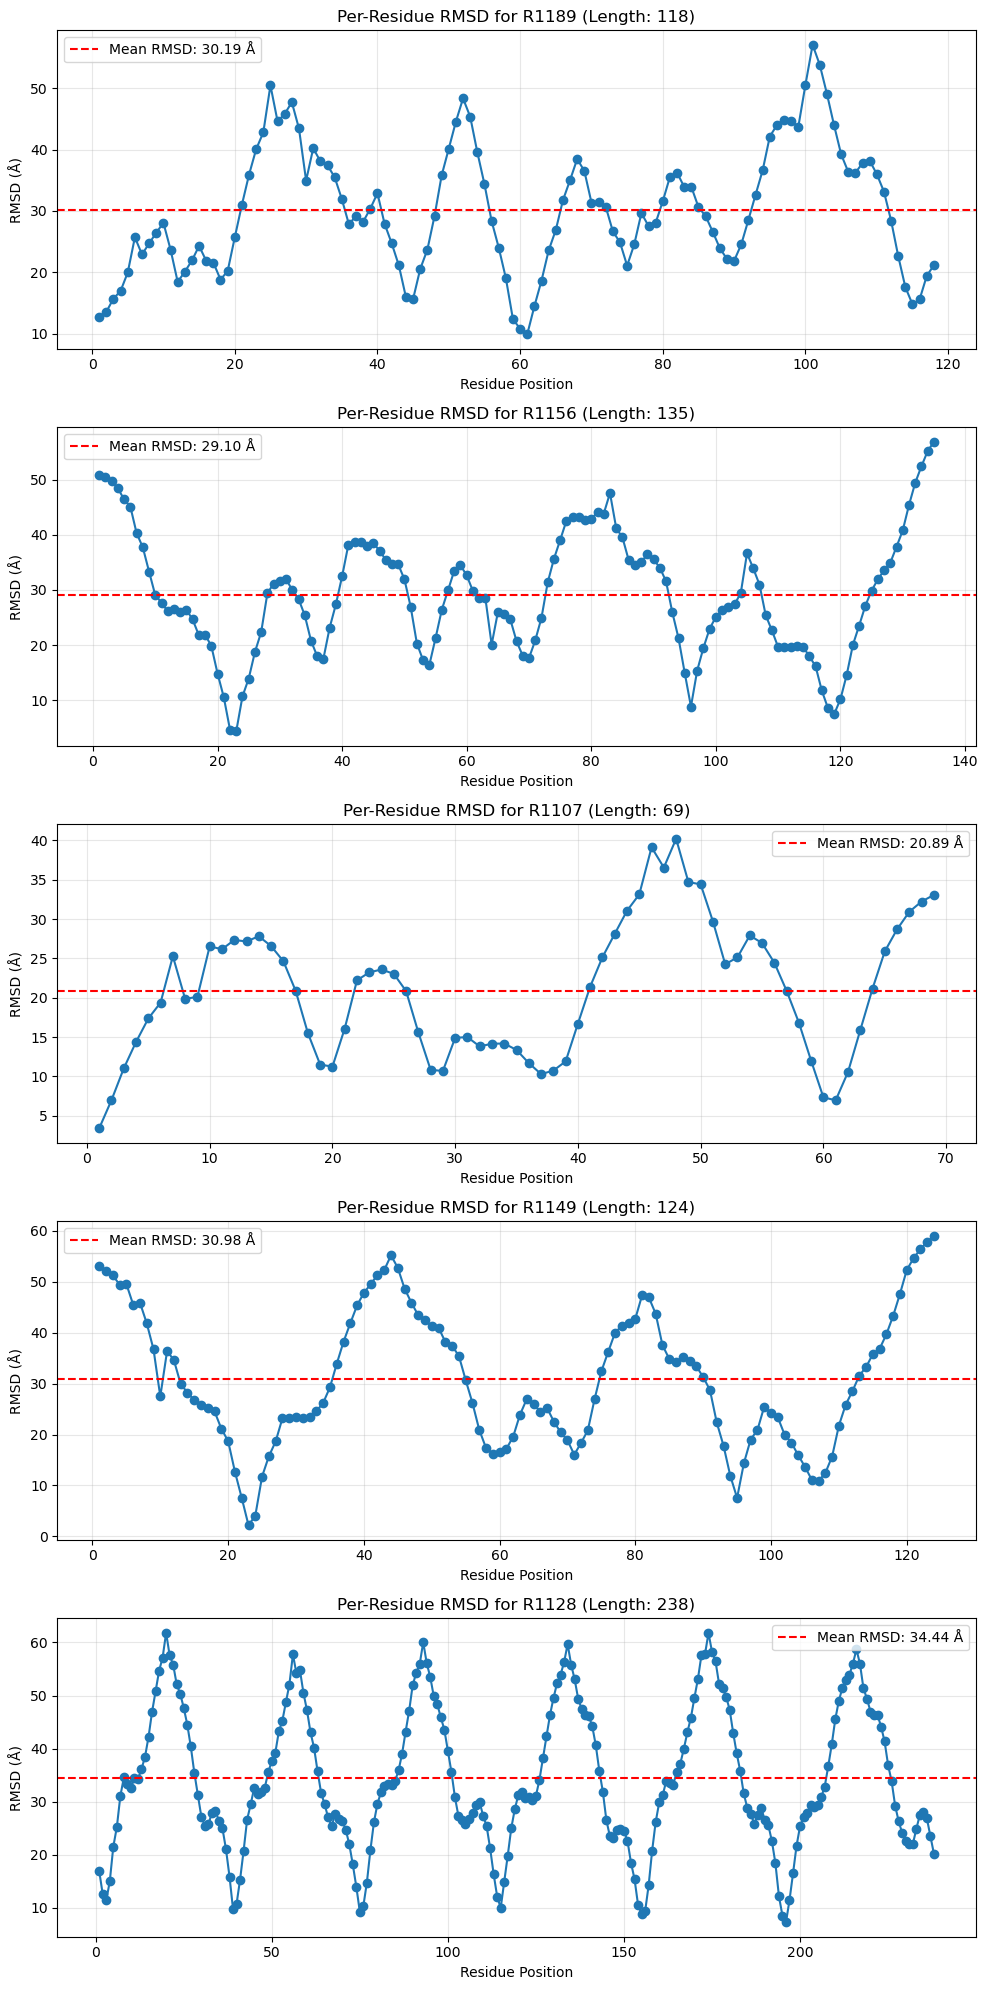

In [8]:
def visualize_per_residue_rmsd(results):
    """Visualize per-residue RMSD for each sequence."""
    num_sequences = len(results["ids"])
    fig, axes = plt.subplots(num_sequences, 1, figsize=(10, 4 * num_sequences))
    
    # Handle case with only one sequence
    if num_sequences == 1:
        axes = [axes]
    
    for i in range(num_sequences):
        per_res_rmsd = results["per_residue_rmsd"][i]
        seq_id = results["ids"][i]
        seq_length = results["sequence_lengths"][i]
        
        ax = axes[i]
        
        # Handle different shapes of per_res_rmsd
        if isinstance(per_res_rmsd, (list, tuple)):
            per_res_rmsd = np.array(per_res_rmsd)
        
        # Handle NaN values
        valid_mask = ~np.isnan(per_res_rmsd)
        valid_indices = np.where(valid_mask)[0]
        valid_values = per_res_rmsd[valid_mask]
        
        if len(valid_values) > 0:
            ax.plot(valid_indices + 1, valid_values, marker='o', linestyle='-')
            
            # Show mean line only if we have valid values
            mean_rmsd = np.mean(valid_values)
            ax.axhline(y=mean_rmsd, color='r', linestyle='--', 
                      label=f'Mean RMSD: {mean_rmsd:.2f} Å')
            
            ax.set_xlabel('Residue Position')
            ax.set_ylabel('RMSD (Å)')
            ax.set_title(f'Per-Residue RMSD for {seq_id} (Length: {seq_length})')
            ax.grid(True, alpha=0.3)
            ax.legend()
        else:
            # Handle the case where all values are NaN or empty
            ax.text(0.5, 0.5, "No valid RMSD values available", 
                    horizontalalignment='center', verticalalignment='center',
                    transform=ax.transAxes, fontsize=12)
            ax.set_title(f'Per-Residue RMSD for {seq_id} (Length: {seq_length})')
    
    plt.tight_layout()
    
    # Save figure
    fig_path = os.path.join(CONFIG["results_dir"], "per_residue_rmsd.png")
    plt.savefig(fig_path)
    print(f"\nSaved per-residue RMSD visualization to {fig_path}")
    
    return fig

# Visualize per-residue RMSD
try:
    per_residue_plot = visualize_per_residue_rmsd(structure_metrics)
except Exception as e:
    print(f"Error visualizing per-residue RMSD: {e}")
    print("This is likely due to the format of per-residue RMSD values.")

## 8. Memory and Performance Benchmarking

Measure memory usage and inference time.

In [9]:
def benchmark_model(model, dataloader, num_runs=3):
    """Benchmark model memory usage and inference time."""
    model.eval()
    
    # Get a batch for benchmarking
    batch = next(iter(dataloader))
    for key in batch:
        if isinstance(batch[key], torch.Tensor):
            batch[key] = batch[key].to(device)
    
    # Measure inference time
    times = []
    
    print("\nBenchmarking model inference time...")
    with torch.no_grad():
        # Warmup run
        _ = model(batch)
        torch.cuda.synchronize() if torch.cuda.is_available() else None
        
        # Timed runs
        for run in range(num_runs):
            start_time = time.time()
            _ = model(batch)
            torch.cuda.synchronize() if torch.cuda.is_available() else None
            end_time = time.time()
            times.append(end_time - start_time)
    
    avg_time = np.mean(times)
    std_time = np.std(times)
    
    # Measure memory usage
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.empty_cache()
        
        # Forward pass to measure memory
        with torch.no_grad():
            _ = model(batch)
        
        # Get memory stats
        peak_memory = torch.cuda.max_memory_allocated(device) / (1024 ** 2)  # MB
        memory_str = f"{peak_memory:.2f} MB"
    else:
        memory_str = "N/A (CPU only)"
    
    print(f"\nPerformance Metrics:")
    print(f"  Inference time (avg of {num_runs} runs): {avg_time:.4f} ± {std_time:.4f} seconds")
    print(f"  Batch size: {CONFIG['batch_size']}")
    print(f"  Peak memory usage: {memory_str}")
    
    # Save results
    benchmark_results = {
        "inference_time": {
            "mean": avg_time,
            "std": std_time,
            "unit": "seconds"
        },
        "batch_size": CONFIG["batch_size"],
        "peak_memory": memory_str
    }
    
    return benchmark_results

# Benchmark model
benchmark_results = benchmark_model(model, validation_loader)

INFO: pairing_probs shape: torch.Size([2, 135, 135])
INFO: coupling_matrix shape: torch.Size([2, 135, 135])
INFO: rel_pos_batch shape: torch.Size([2, 135, 135, 32])
INFO: pair_features_list[0] shape: torch.Size([2, 135, 135, 1])
INFO: pair_features_list[1] shape: torch.Size([2, 135, 135, 1])
INFO: pair_features_list[2] shape: torch.Size([2, 135, 135, 32])
INFO: pairing_probs shape: torch.Size([2, 135, 135])
INFO: coupling_matrix shape: torch.Size([2, 135, 135])
INFO: rel_pos_batch shape: torch.Size([2, 135, 135, 32])
INFO: pair_features_list[0] shape: torch.Size([2, 135, 135, 1])
INFO: pair_features_list[1] shape: torch.Size([2, 135, 135, 1])
INFO: pair_features_list[2] shape: torch.Size([2, 135, 135, 32])
INFO: pairing_probs shape: torch.Size([2, 135, 135])
INFO: coupling_matrix shape: torch.Size([2, 135, 135])
INFO: rel_pos_batch shape: torch.Size([2, 135, 135, 32])
INFO: pair_features_list[0] shape: torch.Size([2, 135, 135, 1])
INFO: pair_features_list[1] shape: torch.Size([2, 135, 


Benchmarking model inference time...

Performance Metrics:
  Inference time (avg of 3 runs): 0.0055 ± 0.0003 seconds
  Batch size: 2
  Peak memory usage: 122.62 MB


## 9. Save Validation Results

Save validation results to a JSON file for future reference.

In [10]:
def save_validation_results(structure_metrics, gradient_status, benchmark_results):
    """Save validation results to a JSON file."""
    # Prepare results for saving
    
    # Filter out NaN values for statistics
    rmsd_values = [r for r in structure_metrics["rmsd"] if not np.isnan(r)]
    tm_values = [r for r in structure_metrics["tm_score"] if not np.isnan(r)]
    
    results = {
        "validation_time": time.strftime("%Y-%m-%d %H:%M:%S"),
        "device": str(device),
        "config": CONFIG,
        "structure_metrics": {
            "rmsd": {
                "mean": float(np.mean(rmsd_values)) if rmsd_values else None,
                "std": float(np.std(rmsd_values)) if rmsd_values else None,
                "per_sequence": [
                    {
                        "id": id, 
                        "length": length, 
                        "rmsd": float(rmsd) if not np.isnan(rmsd) else None
                    } 
                    for id, length, rmsd in zip(
                        structure_metrics["ids"], 
                        structure_metrics["sequence_lengths"], 
                        structure_metrics["rmsd"]
                    )
                ]
            },
            "tm_score": {
                "mean": float(np.mean(tm_values)) if tm_values else None,
                "std": float(np.std(tm_values)) if tm_values else None,
                "per_sequence": [
                    {
                        "id": id, 
                        "length": length, 
                        "tm_score": float(tm_score) if not np.isnan(tm_score) else None
                    } 
                    for id, length, tm_score in zip(
                        structure_metrics["ids"], 
                        structure_metrics["sequence_lengths"], 
                        structure_metrics["tm_score"]
                    )
                ]
            },
            # Per-residue RMSD summary (only means to save space)
            "per_residue_rmsd": {
                "per_sequence": [
                    {
                        "id": id, 
                        "length": length, 
                        "mean_rmsd": float(np.nanmean(per_res_rmsd)) if not np.all(np.isnan(per_res_rmsd)) else None
                    } 
                    for id, length, per_res_rmsd in zip(
                        structure_metrics["ids"], 
                        structure_metrics["sequence_lengths"], 
                        structure_metrics["per_residue_rmsd"]
                    )
                ]
            }
        },
        "gradient_status": {
            "parameters_with_gradient_count": len(gradient_status["parameters_with_gradient"]),
            "parameters_without_gradient_count": len(gradient_status["parameters_without_gradient"]),
            "critical_missing_grad": gradient_status["critical_missing_grad"],
            "loss": gradient_status["loss"]
        },
        "benchmark_results": benchmark_results
    }
    
    # Custom JSON encoder to handle NaN values
    class NpEncoder(json.JSONEncoder):
        def default(self, obj):
            if isinstance(obj, np.integer):
                return int(obj)
            if isinstance(obj, np.floating):
                return float(obj)
            if isinstance(obj, np.ndarray):
                return obj.tolist()
            if np.isnan(obj):
                return None
            return super(NpEncoder, self).default(obj)
    
    # Save to file
    results_file = os.path.join(CONFIG["results_dir"], "validation_results.json")
    with open(results_file, 'w') as f:
        json.dump(results, f, indent=2, cls=NpEncoder)
    
    print(f"\nValidation results saved to {results_file}")
    return results

# Save validation results
validation_results = save_validation_results(structure_metrics, gradient_status, benchmark_results)


Validation results saved to /home/smcgee/MLprojects/RNA 2025/Pipeline-v1-March27on/RNA-2025-Pipeline-v0.2.0-BetaBend/validation/tier1_technical/results/validation_results.json


## 10. Validation Summary

Display a summary of validation results.

In [11]:
def display_summary(validation_results):
    """Display a summary of validation results."""
    print("\n" + "=" * 50)
    print("RNA 3D Folding Model - Technical Validation Summary")
    print("=" * 50)
    print(f"Validation performed on {validation_results['validation_time']}")
    print(f"Device: {validation_results['device']}")
    print("\nStructure Metrics:")
    
    # Handle potentially missing metric values
    rmsd_mean = validation_results['structure_metrics']['rmsd']['mean']
    tm_mean = validation_results['structure_metrics']['tm_score']['mean']
    
    if rmsd_mean is not None:
        print(f"  Mean RMSD: {rmsd_mean:.4f} Å")
    else:
        print("  Mean RMSD: N/A (no valid values)")
        
    if tm_mean is not None:
        print(f"  Mean TM-score: {tm_mean:.4f}")
    else:
        print("  Mean TM-score: N/A (no valid values)")
    
    print("\nGradient Flow:")
    if validation_results['gradient_status']['critical_missing_grad']:
        print(f"  ❌ Critical components missing gradients: {validation_results['gradient_status']['critical_missing_grad']}")
    else:
        print(f"  ✓ All critical components have gradients")
    print(f"  Parameters with gradients: {validation_results['gradient_status']['parameters_with_gradient_count']}")
    print(f"  Total loss: {validation_results['gradient_status']['loss']['total']:.4f}")
    
    print("\nPerformance:")
    print(f"  Inference time: {validation_results['benchmark_results']['inference_time']['mean']:.4f} seconds")
    print(f"  Peak memory usage: {validation_results['benchmark_results']['peak_memory']}")
    
    print("\nSummary:")
    if validation_results['gradient_status']['critical_missing_grad']:
        print("  ❌ FAILED: Gradient flow issues detected")
    else:
        print("  ✓ PASSED: Technical validation successful")
    print("=" * 50)

# Display summary
display_summary(validation_results)

# Export results to markdown
print("\nExporting results to markdown...")
try:
    # Run the export script
    export_script = os.path.join(os.path.dirname(os.getcwd()), "export_notebook_results.py")
    notebook_path = os.path.join(os.getcwd(), "validation_technical.ipynb")
    results_dir = CONFIG["results_dir"]
    output_path = os.path.join(results_dir, "validation_technical_results.md")
    
    # Use os.system to run the script
    cmd = f"python \"{export_script}\" \"{notebook_path}\" \"{output_path}\""
    os.system(cmd)
    
    print(f"Results exported to {output_path}")
except Exception as e:
    print(f"Failed to export results: {e}")
    print("You can manually export results by running ./export_results.sh")


RNA 3D Folding Model - Technical Validation Summary
Validation performed on 2025-04-21 00:57:36
Device: cuda

Structure Metrics:
  Mean RMSD: 31.2419 Å
  Mean TM-score: 0.0430

Gradient Flow:
  ✓ All critical components have gradients
  Parameters with gradients: 59
  Total loss: 9.9509

Performance:
  Inference time: 0.0055 seconds
  Peak memory usage: 122.62 MB

Summary:
  ✓ PASSED: Technical validation successful

Exporting results to markdown...
Results exported to /home/smcgee/MLprojects/RNA 2025/Pipeline-v1-March27on/RNA-2025-Pipeline-v0.2.0-BetaBend/validation/tier1_technical/results/validation_technical_results.md
Results exported to /home/smcgee/MLprojects/RNA 2025/Pipeline-v1-March27on/RNA-2025-Pipeline-v0.2.0-BetaBend/validation/tier1_technical/results/validation_technical_results.md
